<a href="https://colab.research.google.com/github/amrios80/MINE_4210_ADL_202520/blob/main/labs/Laboratorio_7/MINE__4210_ADL_202520_L7_Entregable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202520/blob/main/docs/images/logo.png?raw=true)


# **Laboratorio 7: Redes RNN + Embeddings**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=5KnQpgpopi8a)<br>
[1. Introducción de los datos](#scrollTo=VjA8zwzJvmeO)<br>
[2. Preparación y Modelamiento](#scrollTo=kG8XHROzvuEH)<br>
[3. Taller 3](#scrollTo=JTKc52_Wvs_N)<br>

### **Contexto y Objetivos**

Se requiere realizar el análisis de sentimientos de un conjunto de tweets relacionadas al uso de inteligencia artificial. Con el objetivo de conocer la opinión general y las posibles decisiones a futuro.

### **Objetivos**

1. Analizar la construcción de una Red Neuronal Recurrente.
2. Entrenar una red recurrente LSTM para resolver un problema de análisis de sentimientos.


**Datos:** [tweet-gpt](https://www.kaggle.com/datasets/evilspirit05/tweet-gpt)

### **1. Introducción a los datos**

In [1]:
# Instalación e Importación de librerías
!pip install keras-tuner -q
!pip install contractions -q
!pip install num2words -q

import os
import shutil
from PIL import Image

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
import num2words
from nltk.corpus import stopwords
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

import contractions
import unicodedata
import re

import tensorflow as tf
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, LSTM, TextVectorization, Embedding, SpatialDropout1D

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from google.colab import files
from google.colab import userdata

print('Tensorflow version:', tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 7.0 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tensorflow version: 2.19.0


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"adrianamariarios","key":"636170a31f11fe8cb07f3204ae8200b7"}'}

In [3]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)

# Mover kaggle.json al directorio .kaggle
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

# Dar permisos correctos
os.chmod('/root/.kaggle/kaggle.json', 600)


from google.colab import userdata
userdata.get('adrianamariarios')


!kaggle datasets download -d evilspirit05/tweet-gpt
!unzip "tweet-gpt.zip"


Dataset URL: https://www.kaggle.com/datasets/evilspirit05/tweet-gpt
License(s): MIT
  0% 0.00/9.54M [00:00<?, ?B/s]
100% 9.54M/9.54M [00:00<00:00, 249MB/s]
Archive:  tweet-gpt.zip
  inflating: tweet_gpt.csv           


In [4]:
data = pd.read_csv('/content/tweet_gpt.csv')
data.head(5)

,Date,Tweet,Url,User,UserCreated,UserVerified,UserFollowers,UserFriends,Retweets,Likes,...,New_Date,Time,Hour,Day,TweetStr,hashtags,clean_tweet,sentiment_label,sentiment_score,sentiment
0,2023-04-08 03:31:08+00:00,OpenAI’s GPT-4 Just Got Supercharged! #ai #Cha...,https://twitter.com/tubeblogger/status/1644543...,tubeblogger,2013-06-25 01:42:59+00:00,False,312.0,293.0,0.0,0,...,2023-04-08,03:31:08,3,Saturday,OpenAI’s GPT-4 Just Got Supercharged! #ai #Cha...,"['ai', 'ChatGPT']",openai’s gpt4 just got supercharged!,-,0.917779,positive
1,2023-04-08 03:30:51+00:00,"""Classical art"" is struggling - not changed th...",https://twitter.com/majorradic/status/16445432...,majorradic,2011-12-12 01:29:15+00:00,False,522.0,684.0,0.0,2,...,2023-04-08,03:30:51,3,Saturday,"""Classical art"" is struggling - not changed th...","['ChatGPT', 'chatgpt3', 'AIArtwork', 'AI', 'AI...","classical art"" is struggling not changed the ...",-,0.515711,neutral
2,2023-04-08 03:30:00+00:00,Alibaba invites businesses to trial 'ChatGPT r...,https://twitter.com/gadgetsnow/status/16445430...,gadgetsnow,2010-07-29 10:32:28+00:00,True,90392.0,56.0,0.0,0,...,2023-04-08,03:30:00,3,Saturday,Alibaba invites businesses to trial 'ChatGPT r...,"['Alibaba', 'ChatGPT']",alibaba invites businesses to trial chatgpt ri...,-,0.924410,neutral
3,2023-04-08 03:28:59+00:00,Trying to stop students from using #AI and #ch...,https://twitter.com/Sherab_Taye/status/1644542...,Sherab_Taye,2010-05-10 12:40:40+00:00,False,338.0,53.0,0.0,0,...,2023-04-08,03:28:59,3,Saturday,Trying to stop students from using #AI and #ch...,"['AI', 'chatGPT']",trying to stop students from using and is like...,-,0.636237,negative
4,2023-04-08 03:28:31+00:00,I Asked ChatGPT's AI Chatbot How Can I Earn Cr...,https://twitter.com/cryptoccentral/status/1644...,cryptoccentral,2023-01-27 00:12:12+00:00,False,1.0,2.0,0.0,2,...,2023-04-08,03:28:31,3,Saturday,I Asked ChatGPT's AI Chatbot How Can I Earn Cr...,"['crypto', 'bitcoin', 'cryptocurrency', 'ai', ...",i asked chatgpts ai chatbot how can i earn cry...,-,0.916693,neutral


In [5]:
# Mantenemos el texto y el sentimiento unicamente
data = data[['Tweet', 'sentiment']]
data.head(5)

,Tweet,sentiment
0,OpenAI’s GPT-4 Just Got Supercharged! #ai #Cha...,positive
1,"""Classical art"" is struggling - not changed th...",neutral
2,Alibaba invites businesses to trial 'ChatGPT r...,neutral
3,Trying to stop students from using #AI and #ch...,negative
4,I Asked ChatGPT's AI Chatbot How Can I Earn Cr...,neutral


In [6]:
unique_sentiments = data['sentiment'].unique()

for sentiment in unique_sentiments:
    row = data[data['sentiment'] == sentiment].iloc[0]  # Obtener la primera fila con el valor de sentimiento específico
    print("Sentiment:", sentiment)
    print("Sentence:", row['Tweet'])
    print()


Sentiment: positive
Sentence: OpenAI’s GPT-4 Just Got Supercharged! #ai #ChatGPT  https://t.co/RgMkZlYuRn

Sentiment: neutral
Sentence: "Classical art" is struggling - not changed the fact that is disappearing.

ARTofficial:
It is important that 1/100 passes.
Thousands and thousands will be made.

#ChatGPT #chatgpt3
#AIArtwork #AI #AIPAD
#NFT #Web3 #chatgpt4 #nftarti̇st #AIart #nftart
#NFTJapan #Bing #BingAI

Sentiment: negative
Sentence: Trying to stop students from using #AI and #chatGPT is like trying to stop them from using internet in the early 90s.



In [7]:
data["sentiment"].value_counts()

,count
sentiment,
neutral,19218
positive,11705
negative,6537


### **2. Preparación y Modelamiento**

#### **Preparación**

El objetivo del preprocesamiento es limpiar y estandarizar el texto para que sea más adecuado para su uso.

In [8]:
def remove_stopwords(words):
  for word in STOPWORDS:
    token = ' ' + word + ' '
    words = re.sub(token, ' ', words)
  return words

def preproccesing(words):
    #pasar el texto a minúsculas
    words = words.lower()
    #pasar números a palabras
    #words = re.sub(r"(\d+)", lambda x: num2words.num2words(int(x.group(0))), words)
    #remove_punctuation se omite el caracter - dado que en inglés se usa en palabras compuestas.
    words = re.sub(r"([\"(),¡!¿?:;'></]|\\s)+", "", words)
    #Remove non-ASCII characters
    words = unicodedata.normalize('NFKD', words).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    #Remove Stopwords
    words = remove_stopwords(words)
    #Stem and lemma
    #words = stem_and_lemmatize(words)
    return words

In [9]:
data["Tweet"] = data["Tweet"].apply(contractions.fix)
data["Tweet"] = data["Tweet"].apply(preproccesing)

In [10]:
data['Tweet'].head(5)

,Tweet
0,openais gpt-4 got supercharged #ai #chatgpt h...
1,classical art struggling - changed fact disapp...
2,alibaba invites businesses trial chatgpt rival...
3,trying stop students using #ai #chatgpt like t...
4,i asked chatgpts ai chatbot earn crypto | trad...


Ahora vamos a pasar el sentimiento (clase) a un valor entero usando LabelEncoder

In [11]:
label_encoder = LabelEncoder()
data['sentiment'] = label_encoder.fit_transform(data['sentiment'])

etiquetas_unicas = label_encoder.classes_
for valor_numerico, etiqueta_original in enumerate(etiquetas_unicas):
    print(f'Valor numérico: {valor_numerico}, Etiqueta original: {etiqueta_original}')

Valor numérico: 0, Etiqueta original: negative
Valor numérico: 1, Etiqueta original: neutral
Valor numérico: 2, Etiqueta original: positive


In [12]:
# Divide los datos en entrenamiento y prueba
train, test = train_test_split(data, test_size=0.2, stratify=data['sentiment'], random_state=42, shuffle = True)

# Ahora divide el conjunto de entrenamiento en entrenamiento y validación
train, val = train_test_split(train, test_size=0.2, stratify=train['sentiment'], random_state=42, shuffle = True)

print("Tamaño de datos de entrenamiento:", train.shape)
print("Tamaño de datos de validación:", val.shape)
print("Tamaño de datos de prueba:", test.shape)

train

Tamaño de datos de entrenamiento: (23974, 2)
Tamaño de datos de validación: (5994, 2)
Tamaño de datos de prueba: (7492, 2)


,Tweet,sentiment
8010,every generation mistakenly thinks last. seein...,0
30863,introducing innovative #room22 project owning ...,2
21970,italy bans #chatgpt - interesting move\nhttpst...,2
15743,here another learning angle time #chatgpt admi...,0
8006,wow week never felt safer @gpdp_it blocked #ch...,2
...,...,...
32711,the basic truth behind #chatgpt &amp #chatgpt4...,0
23463,httpst.cokju103bpja\nthat going interesting. ...,2
34292,indian version chatgpt announced soon says min...,1
3502,and still dare offer paid service fuck wrong #...,0


Separamos las oraciones y el sentimiento que representan.


In [13]:
X_train, X_test, X_val= train['Tweet'], test['Tweet'], val['Tweet']
y_train, y_test, y_val= train['sentiment'], test['sentiment'], val['sentiment']

print("x_train", X_train.shape, " y_train:", y_train.shape)
print("x_test:", X_test.shape, "y_test", y_test.shape)
print("x_val", X_val.shape, "y_val:", y_val.shape)

x_train (23974,)  y_train: (23974,)
x_test: (7492,) y_test (7492,)
x_val (5994,) y_val: (5994,)


Revisamos la dristibución de sentimientos del conjunto de entrenamiento:

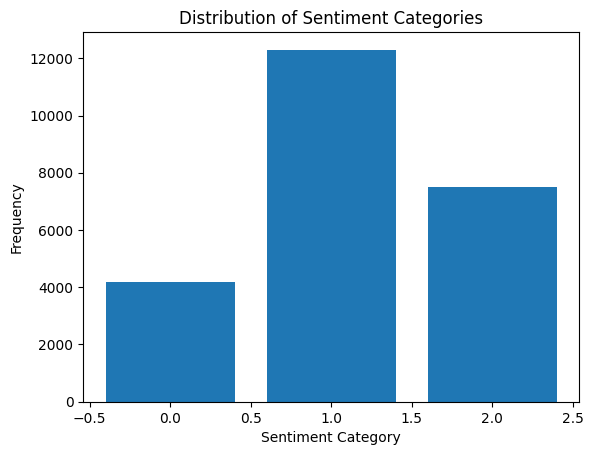

In [14]:
# Create a bar plot to visualize the distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts)
plt.xlabel('Sentiment Category')
plt.ylabel('Frequency')
plt.title('Distribution of Sentiment Categories')
plt.show()

#### **Modelamiento**

Vamos a pasar los datos de texto a un tensor:

In [15]:
X_train_tf = tf.convert_to_tensor(X_train)
X_val_tf = tf.convert_to_tensor(X_val)
X_test_tf = tf.convert_to_tensor(X_test)

X_train_tf

<tf.Tensor: shape=(23974,), dtype=string, numpy=
array([b'every generation mistakenly thinks last. seeing happen chatgpt. #artificialintelligence #openai #ai #chatgpt httpst.cokna5xkddy1',
       b'introducing innovative #room22 project owning #nft means owning piece music earning royalties miss chance part revolutionary concept. check @rocstar22_ \n#chatgpt wrote ',
       b'italy bans #chatgpt - interesting move\nhttpst.co2yngdpykyk',
       ...,
       b'indian version chatgpt announced soon says minister\n@techshotsapp\n\n#chatgpt #indian #it\n\nhttpst.conweel7rvsy',
       b'and still dare offer paid service fuck wrong #chatgpt whole week without access. httpst.cooftnnbff2k',
       b'question everyone.\n\nwill #chatgpt able tell future\n\nif when'],
      dtype=object)>

Ahora hacemos la definición de la capa Vectorize, que se utiliza para tokenización de los textos, y será el punto de entrada de nuestra red neuronal.

[***tf.keras.layers.TextVectorization***](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) es una capa de preprocesamiento que convierte características de texto en secuencias de enteros. Esta capa es útil para preparar datos de texto para su uso en modelos de aprendizaje automático.

El preprocesamiento contiene los siguientes pasos:

*   Normalizar cada ejemplo (normalmente minúsculas + eliminación de puntuación)
*   Dividir cada ejemplo en subcadenas (normalmente palabras).
*   Recombinar las subcadenas en tokens (normalmente ngramas)
*   Indexar los tokens (asociar un valor int único a cada token)
*   Transformar cada ejemplo utilizando este índice, ya sea en un vector de ints o en un vector denso de floats.

In [16]:
#Capa para tokenización
vectorize_layer = TextVectorization(
    standardize=None,
    split = "whitespace",
    #max_tokens=None
    max_tokens=10000, # Set max_tokens to match the embedding layer's input_dim
    output_mode='int',
    output_sequence_length=None)

# El método adapt permite construir el vocabulario.
vectorize_layer.adapt(X_train_tf)

In [17]:
# Tokenizar tus datos
X_train_tk = vectorize_layer(X_train)
X_val_tk = vectorize_layer(X_val)
X_test_tk = vectorize_layer(X_test)

#row_index = 2
print("Texto original en X_train:", X_train[1], end="\n")
print("Texto tokenizado en X_train_tk:", X_train_tk[1])


Texto original en X_train: classical art struggling - changed fact disappearing.

artofficial
it important 1100 passes.
thousands thousands made.

#chatgpt #chatgpt3
#aiartwork #ai #aipad
#nft #web3 #chatgpt4 #nftartist #aiart #nftart
#nftjapan #bing #bingai
Texto tokenizado en X_train_tk: tf.Tensor(
[ 828 1059    1  433 7984  105  857 7984  920  909 4841    1  435  938
  358 2101 9888   38    1    2  490    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0], shape=(65,), dtype=int64)


Veamos como queda la representación del vocabulario del conjunto X_train

In [18]:
print("Vocabulario:", vectorize_layer.get_vocabulary())
print("Configuración:", vectorize_layer.get_config())

Vocabulario: ['', '[UNK]', np.str_('#chatgpt'), np.str_('#ai'), np.str_('ai'), np.str_('chatgpt'), np.str_('#openai'), np.str_('-'), np.str_('#artificialintelligence'), np.str_('like'), np.str_('&amp'), np.str_('i'), np.str_('use'), np.str_('#gpt4'), np.str_('new'), np.str_('using'), np.str_('the'), np.str_('us'), np.str_('data'), np.str_('get'), np.str_('business'), np.str_('#generativeai'), np.str_('could'), np.str_('help'), np.str_('technology'), np.str_('make'), np.str_('via'), np.str_('asked'), np.str_('one'), np.str_('read'), np.str_('#technology'), np.str_('know'), np.str_('language'), np.str_('chat'), np.str_('would'), np.str_('time'), np.str_('future'), np.str_('#chatgpt4'), np.str_('check'), np.str_('think'), np.str_('@openai'), np.str_('#midjourney'), np.str_('learn'), np.str_('better'), np.str_('world'), np.str_('take'), np.str_('#machinelearning'), np.str_('tools'), np.str_('write'), np.str_('see'), np.str_('course'), np.str_('it'), np.str_('gpt'), np.str_('italy'), np.str

Analizamos y visualizamos la longitud de las secuencias de texto en el conjunto de entrenamiento X_train

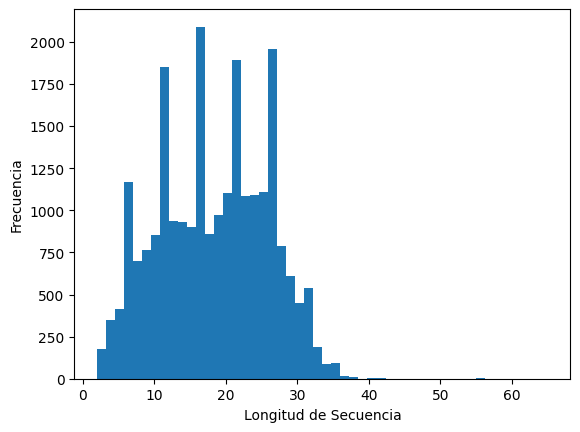

In [19]:
sequence_lengths = [len(text.split()) for text in X_train]
plt.hist(sequence_lengths, bins=50)
plt.xlabel('Longitud de Secuencia')
plt.ylabel('Frecuencia')
plt.show()

In [20]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4),
    # tf.keras.callbacks.TensorBoard(log_dir='/content/logs'),
]

Definiremos la arquitectura de nuestra Red Neuronal Base. Dado que es un problema multiclase se usa ***sparse_categorical_crossentropy*** como función de pérdida y se establecen 3 neuronas en la capa de salida.

Para la entrada usaremos la capa **vectorize_layer** (definida anteriormente), seguido de una capa de **Embedding** que es una de las capas fundamentales en el procesamiento de lenguaje natural (NLP) en modelos de redes neuronales. Su función principal es convertir palabras o tokens en representaciones numéricas, lo que permite que los modelos de aprendizaje automático trabajen con texto.

También usaremos la capa **SpatialDropout1D** es una técnica de regularización que desactiva secuencias completas en lugar de nodos individuales y puede ser útil en modelos de procesamiento de lenguaje natural para prevenir el sobreajuste y mejorar la generalización del modelo.

La capa **LSTM** (Long Short-Term Memory) es una capa especializada en redes neuronales recurrentes (RNN) y secuencias temporales debido a su capacidad para manejar secuencias largas y capturar dependencias a largo plazo.

In [ ]:
model = Sequential()

model.add(vectorize_layer)
model.add(Embedding(10000, 300, name="Capa_Embedding"))
model.add(SpatialDropout1D(0.3))
model.add(LSTM(300, dropout=0.3, recurrent_dropout=0.3))
model.add(Dense(1024, activation='relu', name='Capa_Oculta'))
model.add(Dropout(0.8))
model.add(Dense(3, activation='softmax', name='Capa_Salida'))  # 3 para 3 clases

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
with tf.device('/device:GPU:0'):
  model.fit(
      X_train_tf, y_train,
      validation_data = (X_val_tf, y_val),
      epochs=20,
      callbacks=my_callbacks)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 95s 115ms/step - accuracy: 0.5521 - loss: 0.9689 - val_accuracy: 0.6663 - val_loss: 0.7854
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 135s 112ms/step - accuracy: 0.6983 - loss: 0.7204 - val_accuracy: 0.7122 - val_loss: 0.6671
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 87s 115ms/step - accuracy: 0.8089 - loss: 0.4912 - val_accuracy: 0.7276 - val_loss: 0.6501
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.8614 - loss: 0.3663 - val_accuracy: 0.7222 - val_loss: 0.7226
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 113ms/step - accuracy: 0.8953 - loss: 0.2854 - val_accuracy: 0.7229 - val_loss: 0.8591
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.9192 - loss: 0.2241 - val_accuracy: 0.7140 - val_loss: 0.9200
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 92s 123ms/step - accuracy: 0.9378 - loss: 0.1675 - val_accuracy: 0.7104 - val_loss: 1.0703


Evaluemos el modelo

In [ ]:
y_pred = model.predict(X_train_tf)
y_pred = np.argmax(y_pred, axis=1)
y_pred

750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step


array([0, 2, 1, ..., 1, 0, 1])

In [ ]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      4184
           1       0.97      0.97      0.97     12299
           2       0.97      0.98      0.98      7491

    accuracy                           0.97     23974
   macro avg       0.97      0.96      0.96     23974
weighted avg       0.97      0.97      0.97     23974



In [ ]:
y_pred_test = model.predict(X_test_tf)
y_pred_test = np.argmax(y_pred_test, axis=1)

print(classification_report(y_test, y_pred_test))

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
              precision    recall  f1-score   support

           0       0.61      0.55      0.58      1307
           1       0.75      0.77      0.76      3844
           2       0.72      0.73      0.72      2341

    accuracy                           0.72      7492
   macro avg       0.69      0.68      0.69      7492
weighted avg       0.72      0.72      0.72      7492



Este modelo básico presenta sobreajuste. Para mejorarlo, necesitamos realizar una búsqueda de hiperparámetros para lograr una mejor generalización del modelo como lo pueden ser:

Hiperparámetros de la capa LSTM
*   units
*   dropout y recurrent_dropout

Hiperparámetros de la capa de embedding
*   input_dim
*   output_dim

Hiperparámetros de capas de dropout:
*   rate

Tamaño del vocabulario y longitud de secuencia

Número de capas ocultas

Tamaño del batch y número de épocas


### **3. Taller 3**

-----

**Instrucciones**
1. El archivo a presentar debe ser en formato .ipynb o HTML con sus celdas ejecutadas. Celdas sin ejecutar no podrán ser evaluadas.
2. El nombre del archivo debe ser taller_3_{Apellido_Nombre}_{Apellido_Nombre} de cada integrante del equipo.
3. Las entregas solo se hacen a través de Bloque Neón.

-----

1. ¿Cuáles ajustes aplicaría para solucionar el problema del sobreajuste? Documente los cambios de manera de bulletpoints en una celda markdown y ejecute los cambios al modelo base.

2. Ahora cree un nuevo modelo con un embedding preentrenado [GloVe](https://nlp.stanford.edu/projects/glove/) (http://nlp.stanford.edu/data/glove.6B.zip). ¿Qué pasos adicionales debe implementar para acoplarlo al modelo base del punto 1?
> Por ejemplo la creación de la matriz de incrustración.

3. Genere una búsqueda de hiperparámetros para el modelo base del punto 1 y compárelo con los resultados del modelo del punto 2 en una tabla. ¿Cuáles son sus conclusiones?

### **DESARROLLO DEL TALLER**

**Punto 1**

**A.** Se entrena un modelo modificando el valor de los hiperparametros dropout y recurrent_dropout de la capa LSTM, el valor de estos hiperparametros fue de 0.4, en su evaluacion observamos que el valor general de las metricas precision, F1-score y recall no cambio con respecto al modelo inicial entrenado con valores de dropout y recurrent_dropout igual a 0.3, el valor del parametro unit se disminuyo a 64 teniendo en cuenta que tenemos pocos datos, sin embargo, se observa cambios en las metricas a nivel de las clases, todas las clases mejoraron hasta en 0.02 puntos el recall, la precisión se mejoro solo para la clase 1 y el f1-score mejoro solo para la clase 2.

In [21]:
model = Sequential()

model.add(vectorize_layer)
model.add(Embedding(10000, 300, name="Capa_Embedding"))
model.add(SpatialDropout1D(0.3))
model.add(LSTM(64, dropout=0.4, recurrent_dropout=0.4))
model.add(Dense(1024, activation='relu', name='Capa_Oculta'))
model.add(Dropout(0.8))
model.add(Dense(3, activation='softmax', name='Capa_Salida'))  # 3 para 3 clases

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [22]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [24]:
with tf.device('/device:GPU:0'):
  model.fit(
      X_train_tf, y_train,
      validation_data = (X_val_tf, y_val),
      epochs=20,
      callbacks=my_callbacks)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.5414 - loss: 0.9774 - val_accuracy: 0.6466 - val_loss: 0.8113
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 116ms/step - accuracy: 0.6944 - loss: 0.7285 - val_accuracy: 0.7274 - val_loss: 0.6725
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 117ms/step - accuracy: 0.8053 - loss: 0.5029 - val_accuracy: 0.7367 - val_loss: 0.6600
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 104s 138ms/step - accuracy: 0.8571 - loss: 0.3854 - val_accuracy: 0.7296 - val_loss: 0.6968
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 131ms/step - accuracy: 0.8859 - loss: 0.3129 - val_accuracy: 0.7266 - val_loss: 0.8061
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.9105 - loss: 0.2518 - val_accuracy: 0.7272 - val_loss: 0.9162
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 139s 115ms/step - accuracy: 0.9240 - loss: 0.2060 - val_accuracy: 0.7194 - val_loss: 1.0610


In [26]:
y_pred = model.predict(X_train_tf)
y_pred = np.argmax(y_pred, axis=1)
y_pred

750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step


array([0, 2, 1, ..., 1, 0, 1])

In [29]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      4184
           1       0.97      0.96      0.96     12299
           2       0.96      0.97      0.96      7491

    accuracy                           0.96     23974
   macro avg       0.96      0.96      0.96     23974
weighted avg       0.96      0.96      0.96     23974



In [28]:
y_pred_test = model.predict(X_test_tf)
y_pred_test = np.argmax(y_pred_test, axis=1)

print(classification_report(y_test, y_pred_test))

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
              precision    recall  f1-score   support

           0       0.61      0.57      0.58      1307
           1       0.76      0.75      0.76      3844
           2       0.72      0.75      0.74      2341

    accuracy                           0.72      7492
   macro avg       0.69      0.69      0.69      7492
weighted avg       0.72      0.72      0.72      7492



**B.** En este punto se modifico la capa de embedding y se corrieron dos modelos, en el primero se disminuyo a 5.000 el parametro input_dim y el output_dim en 128 y en el segundo modelo el input_dim se aumento a 100.000 y el output_dim en 300. Se observa que el primer modelo, en la evaluacion, tiene un valor para las metricas menos sobreajustado, el valor del accuracy es del 90% mientras que en las demas evaluaciones ha superado el 95%. En cuanto a la evaluacion del modelo con los datos de prueba, se observaron cambios en las metricas a nivel de las clases asi: un mejor valor para la metrica de F1-score de la clase 0, el f1-score disminuye 0.01 para la clase 1 y se mantiene igual para la clase 2.

In [33]:
model = Sequential()

model.add(vectorize_layer)
model.add(Embedding(5000, 128, name="Capa_Embedding"))
model.add(SpatialDropout1D(0.3))
model.add(LSTM(300, dropout=0.3, recurrent_dropout=0.3))
model.add(Dense(1024, activation='relu', name='Capa_Oculta'))
model.add(Dropout(0.8))
model.add(Dense(3, activation='softmax', name='Capa_Salida'))  # 3 para 3 clases

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [34]:
with tf.device('/device:GPU:0'):
  model.fit(
      X_train_tf, y_train,
      validation_data = (X_val_tf, y_val),
      epochs=20,
      callbacks=my_callbacks)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.5464 - loss: 0.9812 - val_accuracy: 0.6588 - val_loss: 0.7997
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.6800 - loss: 0.7812 - val_accuracy: 0.6732 - val_loss: 0.7716
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.7111 - loss: 0.7048 - val_accuracy: 0.7012 - val_loss: 0.7047
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 119ms/step - accuracy: 0.7569 - loss: 0.5998 - val_accuracy: 0.7181 - val_loss: 0.6763
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.8018 - loss: 0.5082 - val_accuracy: 0.7264 - val_loss: 0.6856
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 118ms/step - accuracy: 0.8249 - loss: 0.4472 - val_accuracy: 0.7236 - val_loss: 0.7064
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.8455 - loss: 0.4051 - val_accuracy: 0.7259 - val_loss: 0.7420
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 144s 120ms/step - accuracy: 0.8572 - loss:

In [35]:
y_pred = model.predict(X_train_tf)
y_pred = np.argmax(y_pred, axis=1)
y_pred

750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step


array([0, 2, 2, ..., 1, 0, 1])

In [36]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4184
           1       0.90      0.92      0.91     12299
           2       0.91      0.92      0.91      7491

    accuracy                           0.90     23974
   macro avg       0.89      0.88      0.88     23974
weighted avg       0.90      0.90      0.90     23974



In [37]:
y_pred_test = model.predict(X_test_tf)
y_pred_test = np.argmax(y_pred_test, axis=1)

print(classification_report(y_test, y_pred_test))

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
              precision    recall  f1-score   support

           0       0.64      0.52      0.57      1307
           1       0.75      0.79      0.77      3844
           2       0.73      0.74      0.73      2341

    accuracy                           0.73      7492
   macro avg       0.70      0.68      0.69      7492
weighted avg       0.72      0.73      0.72      7492



In [45]:
model2 = Sequential()

model2.add(vectorize_layer)
model2.add(Embedding(100000, 128, name="Capa_Embedding"))
model2.add(SpatialDropout1D(0.3))
model2.add(LSTM(300, dropout=0.3, recurrent_dropout=0.3))
model2.add(Dense(1024, activation='relu', name='Capa_Oculta'))
model2.add(Dropout(0.8))
model2.add(Dense(3, activation='softmax', name='Capa_Salida'))  # 3 para 3 clases

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [46]:
with tf.device('/device:GPU:0'):
  model2.fit(
      X_train_tf, y_train,
      validation_data = (X_val_tf, y_val),
      epochs=10,
      callbacks=my_callbacks)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.5369 - loss: 0.9906 - val_accuracy: 0.6512 - val_loss: 0.8059
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 92s 123ms/step - accuracy: 0.6866 - loss: 0.7675 - val_accuracy: 0.6770 - val_loss: 0.7625
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 122ms/step - accuracy: 0.7292 - loss: 0.6609 - val_accuracy: 0.7127 - val_loss: 0.6885
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 124ms/step - accuracy: 0.8020 - loss: 0.5048 - val_accuracy: 0.7276 - val_loss: 0.6600
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 92s 123ms/step - accuracy: 0.8522 - loss: 0.3923 - val_accuracy: 0.7259 - val_loss: 0.7232
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 124ms/step - accuracy: 0.8838 - loss: 0.3249 - val_accuracy: 0.7149 - val_loss: 0.7484
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 124ms/step - accuracy: 0.9039 - loss: 0.2724 - val_accuracy: 0.7167 - val_loss: 0.8020
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 92s 123ms/step - accuracy: 0.9133 - loss: 

In [47]:
y_pred = model2.predict(X_train_tf)
y_pred = np.argmax(y_pred, axis=1)
y_pred

750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step


array([0, 2, 2, ..., 1, 0, 1])

In [48]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      4184
           1       0.95      0.96      0.96     12299
           2       0.97      0.96      0.96      7491

    accuracy                           0.95     23974
   macro avg       0.95      0.95      0.95     23974
weighted avg       0.95      0.95      0.95     23974



In [49]:
y_pred_test = model2.predict(X_test_tf)
y_pred_test = np.argmax(y_pred_test, axis=1)

print(classification_report(y_test, y_pred_test))

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
              precision    recall  f1-score   support

           0       0.62      0.58      0.60      1307
           1       0.75      0.78      0.76      3844
           2       0.74      0.72      0.73      2341

    accuracy                           0.72      7492
   macro avg       0.70      0.69      0.70      7492
weighted avg       0.72      0.72      0.72      7492



**C.** En la capa de dropout cambiamos el valor del hiperparametro rate a 0.5 lo que significa que en el entrenamiento del modelo, el 50% de las neuronas se apagaran. Se observa que evaluando el modelo con el conjunto de entrenamiento, el accuracy es superior al 95% y la diferencia de la metrica con el conjunto de prueba es casi 25 puntos, lo cual sugiere que el modelo continua sobreajustado. El valor de las metricas por clase no tienen una mejora significativa con respecto a los demas modelos que se han ejecutado.

In [50]:
model = Sequential()

model.add(vectorize_layer)
model.add(Embedding(10000, 300, name="Capa_Embedding"))
model.add(SpatialDropout1D(0.3))
model.add(LSTM(300, dropout=0.3, recurrent_dropout=0.3))
model.add(Dense(1024, activation='relu', name='Capa_Oculta'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax', name='Capa_Salida'))  # 3 para 3 clases

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [51]:
with tf.device('/device:GPU:0'):
  model.fit(
      X_train_tf, y_train,
      validation_data = (X_val_tf, y_val),
      epochs=20,
      callbacks=my_callbacks)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 124ms/step - accuracy: 0.5745 - loss: 0.9514 - val_accuracy: 0.6633 - val_loss: 0.8270
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.7109 - loss: 0.7055 - val_accuracy: 0.7174 - val_loss: 0.6766
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.8075 - loss: 0.5015 - val_accuracy: 0.7331 - val_loss: 0.6429
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.8664 - loss: 0.3620 - val_accuracy: 0.7326 - val_loss: 0.7072
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 121ms/step - accuracy: 0.9007 - loss: 0.2743 - val_accuracy: 0.7189 - val_loss: 0.7912
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 92s 122ms/step - accuracy: 0.9247 - loss: 0.2086 - val_accuracy: 0.7149 - val_loss: 0.9791
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.9417 - loss: 0.1650 - val_accuracy: 0.7150 - val_loss: 1.0898


In [52]:
y_pred = model.predict(X_train_tf)
y_pred = np.argmax(y_pred, axis=1)
y_pred

750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step


array([0, 2, 1, ..., 1, 0, 1])

In [53]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4184
           1       0.97      0.98      0.97     12299
           2       0.98      0.97      0.97      7491

    accuracy                           0.97     23974
   macro avg       0.97      0.96      0.97     23974
weighted avg       0.97      0.97      0.97     23974



In [54]:
y_pred_test = model.predict(X_test_tf)
y_pred_test = np.argmax(y_pred_test, axis=1)

print(classification_report(y_test, y_pred_test))

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
              precision    recall  f1-score   support

           0       0.63      0.54      0.58      1307
           1       0.74      0.78      0.76      3844
           2       0.73      0.73      0.73      2341

    accuracy                           0.72      7492
   macro avg       0.70      0.68      0.69      7492
weighted avg       0.72      0.72      0.72      7492



**Punto 2**

In [57]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-10-25 04:34:19--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-10-25 04:34:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-10-25 04:34:19--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [58]:
# Carga el vocabulario y los vectores Glove
embeddings_index = {}
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Total de vectores GloVe cargados: {len(embeddings_index)}")

Total de vectores GloVe cargados: 400000


In [59]:
# Obtiene el vocabulario de Vectoriza layer
vocab = vectorize_layer.get_vocabulary()
word_index = dict(zip(vocab, range(len(vocab))))

In [60]:
# Crea la matriz de embeddings
embedding_dim = 100  # debe coincidir con el GloVe elegido
embedding_matrix = np.zeros((len(vocab), embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [61]:
# Sustituye la capa Embedding por una inicializada con GloVe
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=len(vocab),
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=None,  # o la longitud máxima de tus secuencias
    trainable=False,    # puedes poner True si quieres permitir fine-tuning
    name="Capa_Embedding"
)

model2 = Sequential()
model2.add(vectorize_layer)
model2.add(embedding_layer)
model2.add(SpatialDropout1D(0.3))
model2.add(LSTM(300, dropout=0.3, recurrent_dropout=0.3))
model2.add(Dense(1024, activation='relu', name='Capa_Oculta'))
model2.add(Dropout(0.8))
model2.add(Dense(3, activation='softmax', name='Capa_Salida'))

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [66]:
with tf.device('/device:GPU:0'):
  model2.fit(
      X_train_tf, y_train,
      validation_data = (X_val_tf, y_val),
      epochs=20,
      batch_size=64,
      callbacks=my_callbacks)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step - accuracy: 0.6879 - loss: 0.7184 - val_accuracy: 0.7162 - val_loss: 0.6654
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.6939 - loss: 0.7053 - val_accuracy: 0.7110 - val_loss: 0.6612
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.7034 - loss: 0.6891 - val_accuracy: 0.7187 - val_loss: 0.6435
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 122ms/step - accuracy: 0.7034 - loss: 0.6885 - val_accuracy: 0.7222 - val_loss: 0.6396
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 114ms/step - accuracy: 0.7095 - loss: 0.6767 - val_accuracy: 0.7237 - val_loss: 0.6569
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.7157 - loss: 0.6693 - val_accuracy: 0.7224 - val_loss: 0.6390
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step - accuracy: 0.7140 - loss: 0.6651 - val_accuracy: 0.7211 - val_loss: 0.6330
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.7194 - loss: 0

In [67]:
y_pred = model2.predict(X_train_tf)
y_pred = np.argmax(y_pred, axis=1)
y_pred

750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step


array([0, 2, 2, ..., 1, 0, 1])

In [68]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      4184
           1       0.86      0.78      0.82     12299
           2       0.77      0.88      0.82      7491

    accuracy                           0.80     23974
   macro avg       0.78      0.79      0.79     23974
weighted avg       0.81      0.80      0.80     23974



In [69]:
y_pred_test = model.predict(X_test_tf)
y_pred_test = np.argmax(y_pred_test, axis=1)

print(classification_report(y_test, y_pred_test))

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step
              precision    recall  f1-score   support

           0       0.63      0.54      0.58      1307
           1       0.74      0.78      0.76      3844
           2       0.73      0.73      0.73      2341

    accuracy                           0.72      7492
   macro avg       0.70      0.68      0.69      7492
weighted avg       0.72      0.72      0.72      7492



*##PRUEBA##*

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

In [ ]:
def build_model(hp):
    model = Sequential()

    sequence_length = 100

    # Capa de vectorización fija (ya definida fuera)
    model.add(vectorize_layer)

    # Embedding
    embedding_dim = hp.Choice('embedding_dim', [100, 200, 300])
    model.add(Embedding(input_dim=10000, output_dim=embedding_dim, input_length=sequence_length, name="Capa_Embedding"))

    # Dropout en la capa de embedding
    model.add(SpatialDropout1D(hp.Float('spatial_dropout', 0.1, 0.5, step=0.1)))

    # LSTM
    lstm_units = hp.Int('lstm_units', min_value=64, max_value=512, step=64)
    model.add(LSTM(
        units=lstm_units,
        dropout=hp.Float('lstm_dropout', 0.1, 0.5, step=0.1),
        recurrent_dropout=hp.Float('recurrent_dropout', 0.1, 0.5, step=0.1)
    ))

    # Capa oculta
    dense_units = hp.Int('dense_units', 256, 1024, step=128)
    model.add(Dense(dense_units, activation='relu', name='Capa_Oculta'))

    # Dropout en la capa oculta
    model.add(Dropout(hp.Float('dense_dropout', 0.3, 0.8, step=0.1)))

    # Capa de salida
    model.add(Dense(3, activation='softmax', name='Capa_Salida'))

    # Optimizador y learning rate
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=2,
    #max_trials=10,  # Limita número total de configuraciones
    #executions_per_trial=1,
    directory='kt_dir',
    project_name='lstm_tuning'
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
tuner.search(X_train_tf, y_train, batch_size=16, epochs=5, validation_data=(X_val_tf, y_val), callbacks=[early_stop])

Trial 10 Complete [00h 20m 29s]
val_accuracy: 0.7384050488471985

Best val_accuracy So Far: 0.7384050488471985
Total elapsed time: 03h 47m 52s


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
print(f"Mejor numero de dropout: {best_hps.get('lstm_dropout')}")
print(f"Mejor numero de recurrent_dropout: {best_hps.get('recurrent_dropout')}")
#print(f"Mejor numero de input_dim: {best_hps.get('input_dim')}")
print(f"Mejor numero de output_dim: {best_hps.get('embedding_dim')}")
print(f"Mejor numero de dropout en la capa oculta: {best_hps.get('dense_dropout')}")
print(f"Mejor número de unidades: {best_hps.get('lstm_units')}")
print(f"Mejor número de capas ocultas: {best_hps.get('dense_units')}")
print(f"Mejor tasa de aprendizaje: {best_hps.get('learning_rate')}")

Mejor numero de dropout: 0.5
Mejor numero de recurrent_dropout: 0.2
Mejor numero de output_dim: 100
Mejor numero de dropout en la capa oculta: 0.3
Mejor número de unidades: 256
Mejor número de capas ocultas: 512
Mejor tasa de aprendizaje: 0.0026870545264693364


In [ ]:
model = tuner.hypermodel.build(best_hps)
model.fit(X_train_tf, y_train, epochs=10, validation_data=(X_val_tf, y_val))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


750/750 ━━━━━━━━━━━━━━━━━━━━ 246s 322ms/step - accuracy: 0.5471 - loss: 0.9871 - val_accuracy: 0.6547 - val_loss: 0.8129
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 243s 324ms/step - accuracy: 0.6891 - loss: 0.7542 - val_accuracy: 0.7110 - val_loss: 0.6614
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 242s 323ms/step - accuracy: 0.7789 - loss: 0.5436 - val_accuracy: 0.7271 - val_loss: 0.6584
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 242s 323ms/step - accuracy: 0.8285 - loss: 0.4334 - val_accuracy: 0.7309 - val_loss: 0.6693
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 241s 321ms/step - accuracy: 0.8668 - loss: 0.3525 - val_accuracy: 0.7219 - val_loss: 0.7347
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 242s 323ms/step - accuracy: 0.8855 - loss: 0.2993 - val_accuracy: 0.7304 - val_loss: 0.8014
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 240s 320ms/step - accuracy: 0.8971 - loss: 0.2693 - val_accuracy: 0.7302 - val_loss: 0.8278
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 263s 322ms/step - accuracy: 0.9114 - loss: 0.24

In [ ]:
y_pred = model.predict(X_train_tf)
y_pred = np.argmax(y_pred, axis=1)
y_pred

750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step


array([0, 2, 1, ..., 1, 0, 1])

In [ ]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4184
           1       0.97      0.97      0.97     12299
           2       0.97      0.98      0.97      7491

    accuracy                           0.97     23974
   macro avg       0.96      0.96      0.96     23974
weighted avg       0.97      0.97      0.97     23974



In [ ]:
y_pred_test = model.predict(X_test_tf)
y_pred_test = np.argmax(y_pred_test, axis=1)

print(classification_report(y_test, y_pred_test))

235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step
              precision    recall  f1-score   support

           0       0.60      0.59      0.60      1307
           1       0.76      0.75      0.76      3844
           2       0.72      0.74      0.73      2341

    accuracy                           0.72      7492
   macro avg       0.70      0.70      0.70      7492
weighted avg       0.72      0.72      0.72      7492

